In [ ]:
# This is the most up to date code from langchain. Others we have been using, like the ones from the book of Alammar,
# still work but are a bit out of date


#In many Q&A applications we want to allow the user to have a back-and-forth conversation, meaning the application needs some sort of "memory" of past 
# questions and answers, and some logic for incorporating those into its current thinking.

#Part 2 (this guide) extends the implementation to accommodate conversation-style interactions and multi-step retrieval processes. 

#Here we focus on adding logic for incorporating historical messages. This involves the management of a chat history.

#We will cover two approaches:

    #Chains, in which we execute at most one retrieval step;
    #Agents, in which we give an LLM discretion to execute multiple retrieval steps.

https://python.langchain.com/docs/tutorials/qa_chat_history/

# Loading of documents and other things needed for both approaches

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader 
from pathlib import Path
#from langchain_community.document_loaders.parsers import TesseractBlobParser #In case there are images with text

from langchain_text_splitters import RecursiveCharacterTextSplitter 
#I decided not to use RecursiveCharacterTextSplitter. Maybe it is useful for regular documents, but not for boardgames rulebooks
#Character was also not great since the first splitting hierarchy is /n/n. Decided to keep it with recursive

import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env

from langchain.chat_models import init_chat_model
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 

from langchain_cohere import CohereEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

In [3]:
embeddings = CohereEmbeddings(model="embed-v4.0")
vector_store = InMemoryVectorStore(embeddings)

# For this to work the cohere api key needs to be as env variable with the name COHERE_API_KEY
model = init_chat_model("command-a-03-2025", model_provider="cohere")

In [4]:
# We will also try to make the db with conversations persistent. For this, we use Qdrant as vector store
'''
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

client = QdrantClient(":memory:") # here you have to change something to persist the data
vector_store = QdrantVectorStore(
    client=client,
    collection_name="test",
    embedding=embeddings,
)
'''

'\nfrom langchain_qdrant import QdrantVectorStore\nfrom qdrant_client import QdrantClient\n\nclient = QdrantClient(":memory:") # here you have to change something to persist the data\nvector_store = QdrantVectorStore(\n    client=client,\n    collection_name="test",\n    embedding=embeddings,\n)\n'

In [5]:
#Change prints for logging

In [6]:
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent

path_rules_pdf = base_dir / "data" / 'raw-rulebooks' 

print(path_rules_pdf)

C:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\data\raw-rulebooks


### Load documents

In [7]:
pdf_files = [f.name for f in path_rules_pdf.glob("*.pdf")]
print(pdf_files)

['Paleo_FAQ_11-12-20_ENG.pdf', 'Paleo_Rulebook_EN_compressed.pdf', 'Power-Grid-Recharged-Rules.pdf']


In [8]:
for a_pdf in pdf_files:

    a_loader = PyMuPDFLoader(path_rules_pdf / a_pdf,
                        #mode="single", # Comment this to have different documents per page #The splitter we use appends pages, and it needs to be done without single
                        #extract_tables="markdown", #adds tables at the end of the page
                        #images_inner_format="html-img",  #Did not see huge improvements when using it 
                        #images_parser=TesseractBlobParser(),
                        )
    
    a_doc = a_loader.load()
    # It took less than 1 second without tables
    # extract_tables takes significatnly longer than without it (20 seconds)
    # with tables and images using tesseract (good quality) it took 29 seconds

    print(f'Number of characters of {a_pdf}: {sum([len(a.page_content) for a in a_doc])}') #Total characters

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,  # chunk size (characters)
        chunk_overlap=300,  # chunk overlap (characters)
        add_start_index=True,  # track index in original document
    )

    all_splits = text_splitter.split_documents(a_doc)
    print(f"Split blog post into {len(all_splits)} sub-documents.")

    # Append to each split name of pdf (in case metadata is not included in )
    for a_split in all_splits:
        # added to the chunks both the name of the rule book and the page from the chunk comes from (useful to ask in which page to find something) 
        a_split.page_content = 'Game: ' + a_pdf.split('.')[0] + f', page {a_split.metadata["page"]}' + '. Content: ' + a_split.page_content
        a_split.metadata['game']= a_pdf.split('.')[0] 

    # Add embeddings of the splits into the vector store
    _ = vector_store.add_documents(documents=all_splits)
    print(f'Size of vector store until now: {len(vector_store.store.items())}')

Number of characters of Paleo_FAQ_11-12-20_ENG.pdf: 6817
Split blog post into 7 sub-documents.
Size of vector store until now: 7
Number of characters of Paleo_Rulebook_EN_compressed.pdf: 28907
Split blog post into 27 sub-documents.
Size of vector store until now: 34
Number of characters of Power-Grid-Recharged-Rules.pdf: 42207
Split blog post into 37 sub-documents.
Size of vector store until now: 71


# Approach via Chains

I think that in order for a rag to store memory, we have to change the structure of our state to instead of context, query and answer, to just query and answer. And then we treat everything as if it was a regular chatbot, and add memory to it.

However, it seems that the tutorial wanted us to do that via tools (which are functions that the chatbot can decide to run if it thinks that they are useful in answering the query). Probably they forced us to do it like that to get more used to that approach, since Agents also work like that.

"Conversational experiences (history) can be naturally represented using a sequence of messages. In addition to messages from the user and assistant, retrieved documents and other artifacts can be incorporated into a message sequence via tool messages. This motivates us to represent the state of our RAG application using a sequence of messages."

In [ ]:
#Leveraging tool-calling to interact with a retrieval step has another benefit, which is that the query for the retrieval is generated by our model. (this
# means that the model will decide how to parse the inputs to the tool (function) it decides to use, which could this allow a model to rewrite user queries 
# into more effective ones)

In [62]:
from langchain_core.tools import tool


@tool(response_format="content_and_artifact") # This will make it possible for a chat model to call this function
def retrieve(query: str): # Before, retrieve received a State as input. Now only a string.
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=4)
    serialized = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") #I could modify this to only return useful metadata
        for doc in retrieved_docs 
    )
    print('Retrieval of data successful')
    return serialized, retrieved_docs  # if you use @tool(response_format="content_and_artifact"), you must return exactly a tuple of two elements

#First element → This is what will be used as the main textual output (like a summary or answer).
#Second element → This is any additional data (e.g. a document, list of sources, JSON, etc.) that might be useful for tracking, inspection, or chaining.


Our graph will consist of three nodes:

1- A node that fields the user input, either generating a query for the retriever or responding directly; **(this is cool and we did not have it before. an answer can now come from the context, or from the previous messages. In the previous implementation, no matter how much prompt engineering we did, even if we added memory to the rag, we would always be extracting info from the vector space and adding them into the query. Now only when the history does not know the answer)**

2- A node for the retriever tool that executes the retrieval step;

3- A node that generates the final response using the retrieved context.

In [ ]:


#output_1= query_or_respond({"messages": [{"role": "user", "content": 'How do you win at paleo?'}]})

#input_for_retrieve = output_1['messages'][0].additional_kwargs['tool_calls'][0]['function']['arguments']

#retrieve(input_for_retrieve)

C:\Users\Carlos Ivan\AppData\Local\Temp\ipykernel_5796\1724599674.py:5: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieve(input_for_retrieve)


{'messages': [AIMessage(content="I will search for 'how do you win at paleo?'", additional_kwargs={'id': '09060a47-eecb-4d7f-89ee-3e4a4523c932', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at paleo?'", 'tool_calls': [{'id': 'retrieve_g7vgxpxcapyv', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"How do you win at paleo?"}'}}], 'token_count': {'input_tokens': 1433.0, 'output_tokens': 53.0}}, response_metadata={'id': '09060a47-eecb-4d7f-89ee-3e4a4523c932', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at paleo?'", 'tool_calls': [{'id': 'retrieve_g7vgxpxcapyv', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"How do you win at paleo?"}'}}], 'token_count': {'input_tokens': 1433.0, 'output_tokens': 53.0}}, id='run--5b6148be-8308-4228-aaaa-bf3c6a54f933-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'How do you win at paleo?'}, 'id': 'retrieve_g7vgxpxcapyv', 'type

"Source: {'producer': 'macOS Version 10.14.6 (Build 18G6020) Quartz PDFContext', 'creator': 'Adobe InDesign 15.1 (Windows)', 'creationdate': '2020-10-21T20:15:10+00:00', 'source': 'C:\\\\Users\\\\Carlos Ivan\\\\Documents\\\\Projects\\\\boardgames-assistant\\\\data\\\\raw-rulebooks\\\\Paleo_Rulebook_EN_compressed.pdf', 'file_path': 'C:\\\\Users\\\\Carlos Ivan\\\\Documents\\\\Projects\\\\boardgames-assistant\\\\data\\\\raw-rulebooks\\\\Paleo_Rulebook_EN_compressed.pdf', 'total_pages': 12, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-10-21T20:51:38+00:00', 'trapped': '', 'modDate': 'D:20201021205138Z', 'creationDate': 'D:20201021201510Z', 'page': 1, 'start_index': 1206, 'game': 'Paleo_Rulebook_EN_compressed'}\nContent: Game: Paleo_Rulebook_EN_compressed, page 1. Content: look at the cards too closely when you sort them. How to sort the cards is described in \n“Card Setup” on the right.\n• During most games, you will use only 2 of the 10 i

In [82]:
# We generate these nodes here

from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState, StateGraph
from langgraph.prebuilt import ToolNode



# Node 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = model.bind_tools([retrieve]) # Tells the chat model it can use the retrieve tool
    response = llm_with_tools.invoke(state["messages"]) 
    #response is an AIMessage object with the content of the message and some metadata
    # This metadata also says if you most call a Tool or not, and which function
    # MessagesState appends messages to state instead of overwriting
    output = {"messages": [response]}
    print(output)
    return output


# Node 2: Execute the retrieval.
#ToolNode executes the tool and adds the result as a ToolMessage to the state. (This is important info)
#I think this addition only happens when running it inside a graph for a particular state, not if you run it independently
tools = ToolNode([retrieve])


# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: MessagesState): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        #print(message.content) #Useful to see what is appended in the message
        if message.type == "tool":
            recent_tool_messages.append(message.content) #appends only tool messages'content (not metadata!) (outputs from the retriever)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #orders them from first to last 

    # Format into prompt
    docs_content = "\n\n".join(doc for doc in tool_messages) # I dont see the need of this if we already joined contexts in tools. 
    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (outputs of the retriever are already added in system_message_content)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    print(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    return {"messages": [response]} # MessagesState appends messages to state instead of overwriting

In [83]:
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition



graph_builder = StateGraph(MessagesState)



graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

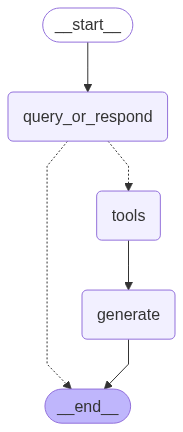

In [73]:
# To visualize flow: 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Testing

In [91]:
#input_message='How do you win at paleo?'
input_message='What was my last question?'
#input_message='Good morning Cohere chatbot!'
#input_message='Up to how many players can Monopoly be played?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]})

{'messages': [AIMessage(content="I'm sorry, I don't have access to information about your previous questions.", additional_kwargs={'id': '7c33bf6b-3390-417e-9532-fb7cbae8e656', 'finish_reason': 'COMPLETE', 'content': "I'm sorry, I don't have access to information about your previous questions.", 'token_count': {'input_tokens': 1432.0, 'output_tokens': 18.0}}, response_metadata={'id': '7c33bf6b-3390-417e-9532-fb7cbae8e656', 'finish_reason': 'COMPLETE', 'content': "I'm sorry, I don't have access to information about your previous questions.", 'token_count': {'input_tokens': 1432.0, 'output_tokens': 18.0}}, id='run--c828f4fb-d134-4d0a-8b70-6affb025ffc6-0', usage_metadata={'input_tokens': 1432, 'output_tokens': 18, 'total_tokens': 1450})]}


{'messages': [HumanMessage(content='What was my last question?', additional_kwargs={}, response_metadata={}, id='ec601d89-4a03-4cfe-8a16-96795e89de67'),
  AIMessage(content="I'm sorry, I don't have access to information about your previous questions.", additional_kwargs={'id': '7c33bf6b-3390-417e-9532-fb7cbae8e656', 'finish_reason': 'COMPLETE', 'content': "I'm sorry, I don't have access to information about your previous questions.", 'token_count': {'input_tokens': 1432.0, 'output_tokens': 18.0}}, response_metadata={'id': '7c33bf6b-3390-417e-9532-fb7cbae8e656', 'finish_reason': 'COMPLETE', 'content': "I'm sorry, I don't have access to information about your previous questions.", 'token_count': {'input_tokens': 1432.0, 'output_tokens': 18.0}}, id='run--c828f4fb-d134-4d0a-8b70-6affb025ffc6-0', usage_metadata={'input_tokens': 1432, 'output_tokens': 18, 'total_tokens': 1450})]}

In [93]:
input_message='How do you win at power grid?'

graph.invoke({"messages": [{"role": "user", "content": input_message}]})

{'messages': [AIMessage(content="I will search for 'how do you win at power grid?'", additional_kwargs={'id': '1fa79145-c69d-4518-906d-c4d10aab3eaf', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at power grid?'", 'tool_calls': [{'id': 'retrieve_v4cgftnbd902', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how do you win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 54.0}}, response_metadata={'id': '1fa79145-c69d-4518-906d-c4d10aab3eaf', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at power grid?'", 'tool_calls': [{'id': 'retrieve_v4cgftnbd902', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how do you win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 54.0}}, id='run--c8007a1e-5a66-4bf9-b840-48da78e122ce-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'how do you win at power grid'}, 'id': 're

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='5721990c-1556-49fe-a409-8a86ec4e6e79'),
  AIMessage(content="I will search for 'how do you win at power grid?'", additional_kwargs={'id': '1fa79145-c69d-4518-906d-c4d10aab3eaf', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at power grid?'", 'tool_calls': [{'id': 'retrieve_v4cgftnbd902', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how do you win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 54.0}}, response_metadata={'id': '1fa79145-c69d-4518-906d-c4d10aab3eaf', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at power grid?'", 'tool_calls': [{'id': 'retrieve_v4cgftnbd902', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how do you win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 54.0}},

In [92]:
input_message = "How do you win at Power grid?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

How do you win at Power grid?
{'messages': [AIMessage(content="I will search for 'how to win at power grid'.", additional_kwargs={'id': '9c3de7c2-df34-4362-8475-ec36492875e3', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_f67b4y6sengg', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, response_metadata={'id': '9c3de7c2-df34-4362-8475-ec36492875e3', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_f67b4y6sengg', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, id='run--2eadf2b0-c0f9-4603-bb57-8186bc3b58e9-0', t

# Via Agents

# Search and generation

In [8]:

from langchain.prompts import ChatPromptTemplate

prompt_ours = ChatPromptTemplate.from_messages([
    ("system", "You are an assistant for question-answering tasks. "
               "Use the following pieces of retrieved context to answer the question. "
               "If you don't know the answer, just say that you don't know, don't try to make up an answer."
               "Use between three to 5 sentences maximum and keep the answer concise."),
    ("human", "Question: {question}\nContext: {context}\nAnswer:")
])


In [10]:
prompt_ours.invoke({"question": 'Who is the Taats Foo', "context": 'The Toot is the Foo of the Taat'})

ChatPromptValue(messages=[SystemMessage(content="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer.Use between three to 5 sentences maximum and keep the answer concise.", additional_kwargs={}, response_metadata={}), HumanMessage(content='Question: Who is the Taats Foo\nContext: The Toot is the Foo of the Taat\nAnswer:', additional_kwargs={}, response_metadata={})])

# Testing rag

In [16]:
# Add the extensions of powergrid

In [17]:
for message, metadata in graph.stream(
    {"question": "What is the number of playable regions in powergrid?"}, stream_mode="messages"
):
    print(message.content, end="")

The number of playable regions in Power Grid depends on the number of players and the chosen map. For the Germany map, there are 6 areas, each with 7 cities. Players choose a contiguous playing zone of connected areas, which can vary based on the number of players. For example, in a 2-player game, a smaller zone might be selected, while a larger zone is used for more players. The exact number of regions in the playing zone is not fixed but is determined by the players' choice during setup.

In [20]:
result = graph.invoke({"question": "In which page can I read what happens after step 3 starts?"})


In [21]:
print(f"Answer: {result['answer']}")


Answer: You can read what happens after Step 3 starts on **page 11** of the Power-Grid-Recharged-Rules. This page details the changes and rules specific to Step 3, including adjustments to the power plant market, city network rules, building costs, and resource resupply.


In [27]:
result

{'question': 'Up to how many people can play powergrid?',
 'context': [Document(id='233508cc-6aad-4bc2-ac12-170ec6189836', metadata={'producer': 'Adobe PDF Library 8.0', 'creator': 'Adobe InDesign CS3 (5.0.4)', 'creationdate': '2018-07-26T15:22:09+02:00', 'source': 'C:\\Users\\Carlos Ivan\\Documents\\Projects\\boardgames-assistant\\data\\raw-rulebooks\\Power-Grid-Recharged-Rules.pdf', 'file_path': 'C:\\Users\\Carlos Ivan\\Documents\\Projects\\boardgames-assistant\\data\\raw-rulebooks\\Power-Grid-Recharged-Rules.pdf', 'total_pages': 12, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-05-08T13:58:23-04:00', 'trapped': '', 'modDate': "D:20200508135823-04'00'", 'creationDate': "D:20180726152209+02'00'", 'page': 7, 'start_index': 0}, page_content='Power-Grid-Recharged-Rules: Number of players\n2\n3–4\n5\n6\nConnected cities\n18\n17\n15\n14\n!\nExample: For 3–4 players, the game ends after \na player connects 17 cities.\nStep 3\nWhen you draw t

64

In [18]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You talk like a pirate. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"), #the variable name is important. MessagesState has that field
    ]
)
#Note that we have added a new language input to the prompt. Our application now has two parameters-- the input messages 
# and language. We no longer can use the MessagesState class since it does not contain the field language. Hence,
# we create a custom message state class


from typing import Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated, TypedDict


class StateWithLanguage(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str

In [ ]:




# Trimmer to manage memory. In the future, we could change that for a summary of all the history
trimmer = trim_messages(
    max_tokens=5000, #maximum context length of command a is 254k tokens
    strategy="last",
    token_counter=model,
    include_system=True,
    allow_partial=False,
    start_on="human",
)    


# Define the function that calls the model
def call_model(state: StateWithLanguage): # Without language var it was state: MessagesState
    trimmed_messages = trimmer.invoke(state["messages"]) #Avoids overflowing history
    prompt = prompt_template.invoke(
        {"messages": trimmed_messages, "language": state["language"]}
    )
    response = model.invoke(prompt) # Without the prompt template it was model.invoke(state["messages"])
    return {"messages": [response]} #Are the [] needed?



# Define a new graph
workflow = StateGraph(state_schema=StateWithLanguage) # Without language var it was state_schema=MessagesState

# Define the (single) node in the graph
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)